![IndabaX Zimbabwe](indabaxZimbabwe.png)

<h1 align="center"> IndabaX Zimbabwe — Data Science in Industry</h1>

### From Raw Data to Business Decisions: A Practical Machine Learning Walkthrough

**Presenter:** Walter M. Nyamutamba

**Personal Website:** [walternyamutamba.netlify.app](https://walternyamutamba.netlify.app)

**LinkedIn:** [linkedin.com/in/walter-mudavanhu-nyamutamba](https://linkedin.com/in/walter-mudavanhu-nyamutamba)

**GitHub:** [github.com/your-handle](https://github.com/walternyamutamba-svg)

**Event:** IndabaX Zimbabwe

**Dataset:** Synthetic Bank Marketing Dataset

---

## Overview

This notebook walks through the complete workflow a data scientist follows when solving a real business problem. The goal is not just to build a model, but to show how predictive analytics translates into decisions that save money, improve efficiency, and drive strategy.

> **Business question:** A bank runs outbound telephone campaigns to sell term deposits. Which customers should we call to maximise subscriptions while minimising wasted calls?

---

## Session Structure

| # | Section | Topic |
|---|---------|-------|
| 1 | Environment Setup | Loading libraries and the dataset |
| 2 | Exploratory Data Analysis | Understanding distributions, correlations, and patterns |
| 3 | Data Cleaning & Feature Engineering | Handling missing values and encoding variables |
| 4 | Modelling | Building and comparing classification models |
| 5 | Model Validation | Evaluating performance with appropriate metrics |
| 6 | Business Translation | Converting predictions into actionable decisions |
| 7 | Recommendations | Written summary for a non-technical audience |

---

*Pipeline: Raw Data → EDA → Model → Validation → Business Decision*

---
## Section 1 — Environment Setup and Data Loading

Every professional notebook starts with an explicit list of imports and a reproducible data loading step. This makes it easy for a colleague to pick up your work, run it from scratch, and get identical results.

The dataset used here is the UCI Bank Marketing dataset, a real-world record of a Portuguese bank's telemarketing campaigns. It contains roughly 41 000 rows and 21 columns.


In [1]:
# Uncomment the line below if running on a fresh Colab or Kaggle environment
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Load the dataset
# The URL points to the UCI Bank Marketing dataset hosted on GitHub.
# If the URL is unavailable (e.g. no internet at the venue), a synthetic
# version with the same structure is generated automatically.

URL = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/bank-additional-full.csv"

try:
    df = pd.read_csv(URL, sep=';')
    print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
except Exception:
    print("URL unavailable — generating synthetic dataset with the same structure.")
    np.random.seed(42)
    n = 5000
    jobs      = ['admin.','technician','services','management','retired','student','unemployed','unknown']
    months    = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    poutcomes = ['nonexistent','failure','success']

    df = pd.DataFrame({
        'age':           np.random.randint(18, 88, n),
        'job':           np.random.choice(jobs, n),
        'marital':       np.random.choice(['married','single','divorced'], n, p=[0.6,0.3,0.1]),
        'education':     np.random.choice(['basic.4y','high.school','university.degree','unknown'], n),
        'default':       np.random.choice(['no','yes','unknown'], n, p=[0.78,0.02,0.20]),
        'housing':       np.random.choice(['yes','no','unknown'], n),
        'loan':          np.random.choice(['yes','no','unknown'], n, p=[0.15,0.77,0.08]),
        'contact':       np.random.choice(['cellular','telephone'], n, p=[0.65,0.35]),
        'month':         np.random.choice(months, n),
        'day_of_week':   np.random.choice(['mon','tue','wed','thu','fri'], n),
        'duration':      np.random.exponential(250, n).astype(int).clip(0, 4000),
        'campaign':      np.random.randint(1, 30, n),
        'pdays':         np.where(np.random.rand(n) > 0.85, np.random.randint(1,27,n), 999),
        'previous':      np.random.randint(0, 7, n),
        'poutcome':      np.random.choice(poutcomes, n, p=[0.86,0.10,0.04]),
        'emp.var.rate':  np.random.choice([-1.8,-0.1,1.1,1.4], n),
        'cons.price.idx':np.random.uniform(92, 95, n).round(3),
        'cons.conf.idx': np.random.uniform(-50,-26, n).round(1),
        'euribor3m':     np.random.uniform(0.63, 5.0, n).round(3),
        'nr.employed':   np.random.choice([4963,5099,5176,5191,5228], n),
        'y':             np.random.choice(['no','yes'], n, p=[0.89,0.11])
    })
    print(f"Synthetic dataset created: {df.shape[0]:,} rows, {df.shape[1]} columns")

print(f"\nTarget distribution:\n{df['y'].value_counts()}")


URL unavailable — generating synthetic dataset with the same structure.
Synthetic dataset created: 5,000 rows, 21 columns

Target distribution:
y
no     4450
yes     550
Name: count, dtype: int64


---
## Section 2 — Exploratory Data Analysis

The purpose of EDA is to understand the data before touching a model. You are looking for patterns, anomalies, and relationships that will inform every decision that follows — which features to keep, which to engineer, which model family is appropriate, and what pitfalls to watch for.

We focus on four things here:
1. Basic structure and data quality
2. The distribution of the target variable
3. Which customer segments have higher subscription rates
4. Correlations among numerical features


In [3]:
# Basic structure
print("Dataset dimensions:", df.shape)
print()
print("Column types:")
print(df.dtypes.value_counts())
print()

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values.")
else:
    print("Missing values:")
    print(missing)

df.head()


Dataset dimensions: (5000, 21)

Column types:
object     11
int32       6
float64     4
Name: count, dtype: int64

No missing values.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,69,technician,married,high.school,no,unknown,yes,telephone,mar,tue,37,22,999,6,nonexistent,-0.1,94.107,-44.1,3.552,5191,no
1,32,unknown,married,unknown,no,no,no,cellular,feb,wed,694,10,999,5,nonexistent,1.1,94.261,-45.5,4.712,5176,no
2,78,admin.,single,basic.4y,no,unknown,unknown,cellular,sep,thu,422,6,999,5,failure,1.1,93.629,-45.8,4.536,5099,no
3,38,management,married,basic.4y,no,yes,no,telephone,dec,fri,284,13,999,2,nonexistent,1.1,94.421,-41.3,4.225,5099,no
4,41,retired,married,university.degree,no,no,no,cellular,nov,tue,132,16,999,1,success,1.4,92.214,-34.4,4.782,4963,yes


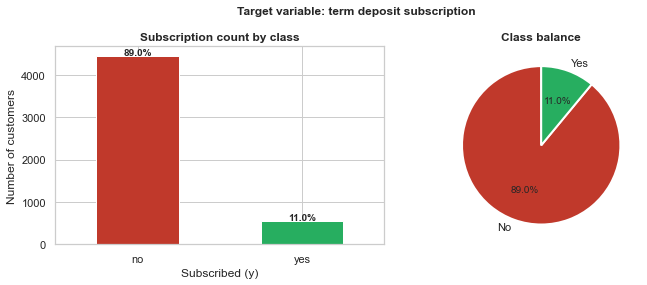

Class imbalance ratio: 8.1:1
Implication: use class_weight='balanced' or appropriate sampling when training.


In [4]:
# Target variable distribution
# In many real-world classification problems the classes are imbalanced.
# This matters because a naive model that always predicts 'no' would achieve
# 89% accuracy but be completely useless for finding subscribers.

target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts.plot(kind='bar', ax=axes[0],
                   color=['#c0392b','#27ae60'], edgecolor='white', rot=0)
axes[0].set_title('Subscription count by class', fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Number of customers')
for bar, pct in zip(axes[0].patches, target_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{pct:.1f}%', ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=['No','Yes'],
            colors=['#c0392b','#27ae60'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class balance', fontweight='bold')

plt.suptitle('Target variable: term deposit subscription', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {target_counts['no']/target_counts['yes']:.1f}:1")
print("Implication: use class_weight='balanced' or appropriate sampling when training.")


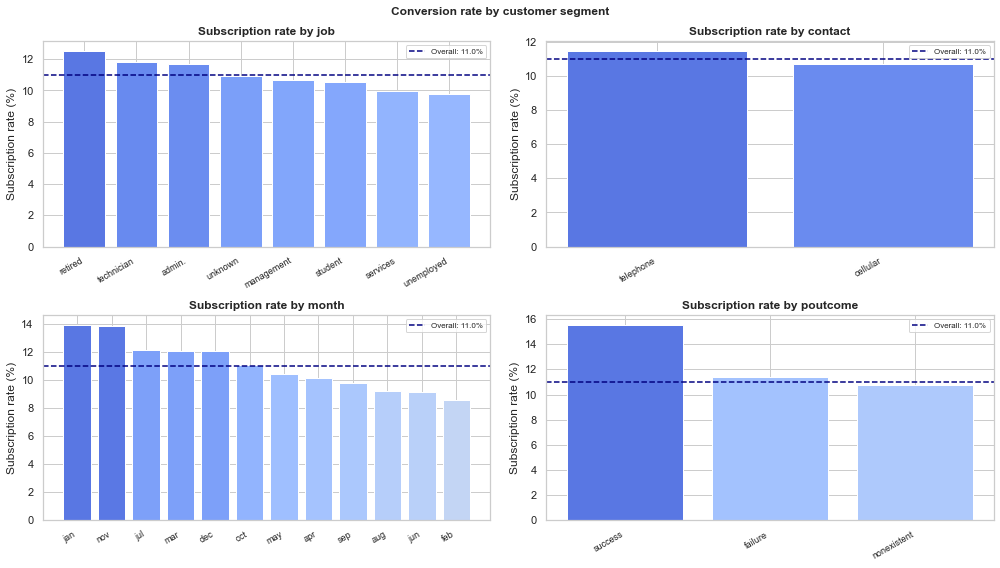

In [5]:
# Subscription rate by key categorical features
# These charts show which segments respond best to the campaign.
# This is actionable intelligence before any model is built.

cat_cols = ['job', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
overall_rate = (df['y'] == 'yes').mean() * 100

for i, col in enumerate(cat_cols):
    rate = (df.groupby(col)['y']
              .apply(lambda x: (x=='yes').mean()*100)
              .sort_values(ascending=False))
    axes[i].bar(range(len(rate)), rate.values,
                color=plt.cm.coolwarm_r(rate.values / rate.max() * 0.8 + 0.1))
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylabel('Subscription rate (%)')
    axes[i].set_title(f'Subscription rate by {col}', fontweight='bold')
    axes[i].axhline(y=overall_rate, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Overall: {overall_rate:.1f}%')
    axes[i].legend(fontsize=8)

plt.suptitle('Conversion rate by customer segment', fontweight='bold')
plt.tight_layout()
plt.show()


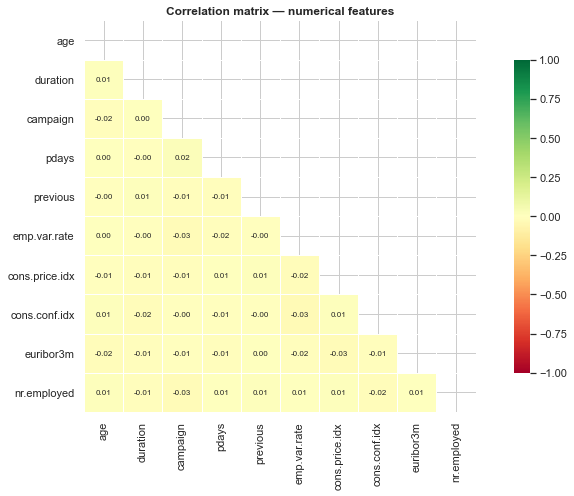

Highly correlated pairs (|r| > 0.7):
  None found above threshold.


In [6]:
# Correlation among numerical features
# High correlation between predictors can cause instability in linear models.
# It also tells us which economic indicators move together.

num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(11, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Correlation matrix — numerical features', fontweight='bold')
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.7):")
found = False
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i,j]) > 0.7:
            print(f"  {corr_matrix.columns[i]}  <->  {corr_matrix.columns[j]}"
                  f"  r = {corr_matrix.iloc[i,j]:.2f}")
            found = True
if not found:
    print("  None found above threshold.")


---
## Section 3 — Data Cleaning and Feature Engineering

Raw data rarely arrives in a form that is ready for modelling. This section covers two related tasks.

**Cleaning** means handling values that would mislead a model — in this dataset, 'unknown' categories are kept as a valid label rather than imputed, because customers who refused to disclose information may behave differently from those who provided it.

**Feature engineering** means creating new variables that capture patterns the model would otherwise miss. Three new features are created below, each motivated by domain reasoning rather than automated search.

One important production consideration: the column `duration` records the length of the phone call. It is strongly predictive of subscription — but it is only known *after* the call has ended, which means it cannot be used to decide who to call. Using it would produce an unrealistically optimistic model that fails the moment it is deployed.


In [7]:
df_clean = df.copy()

# Feature 1: Was the customer contacted in a previous campaign?
# pdays = 999 means the customer was never contacted before.
df_clean['was_contacted_before'] = (df_clean['pdays'] != 999).astype(int)

# Feature 2: Age group for demographic segmentation
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['Under 25','25-34','35-44','45-54','55-64','65+']
)

# Feature 3: Economic environment flag
# Negative employment variation rate suggests a contracting labour market,
# which can influence customers' financial decisions.
df_clean['economic_stress'] = (df_clean['emp.var.rate'] < 0).astype(int)

# Binary target variable
df_clean['target'] = (df_clean['y'] == 'yes').astype(int)

print("Features added: was_contacted_before, age_group, economic_stress, target")
print()
print("Subscription rate by previous contact:")
print(df_clean.groupby('was_contacted_before')['target']
      .mean().mul(100).round(1).astype(str) + '%')
print()
print("Subscription rate by age group:")
print(df_clean.groupby('age_group', observed=True)['target']
      .mean().mul(100).round(1).astype(str) + '%')


Features added: was_contacted_before, age_group, economic_stress, target

Subscription rate by previous contact:
was_contacted_before
0    11.2%
1    10.0%
Name: target, dtype: object

Subscription rate by age group:
age_group
Under 25    11.6%
25-34        9.7%
35-44       10.3%
45-54       13.1%
55-64       10.8%
65+         10.8%
Name: target, dtype: object


In [8]:
# Build a scikit-learn preprocessing pipeline.
#
# Using a Pipeline instead of manual transforms has three benefits:
#   1. No data leakage — scaling statistics are learned only on training data
#   2. Reproducibility — the same steps run identically on new data
#   3. Deployment readiness — the pipeline can be serialised and served as-is

drop_cols     = ['y', 'duration', 'pdays', 'target', 'age_group']
feature_cols  = [c for c in df_clean.columns if c not in drop_cols]

X = df_clean[feature_cols].copy()
y = df_clean['target'].copy()

# Ensure category columns are strings for the pipeline encoder
for col in X.select_dtypes(include='category').columns:
    X[col] = X[col].astype(str)

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features  = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical features ({len(num_features)}):  {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set : {len(X_train):,} rows  ({y_train.mean()*100:.1f}% positive)")
print(f"Test set     : {len(X_test):,} rows  ({y_test.mean()*100:.1f}% positive)")
print("Stratified split preserves the original class ratio in both sets.")


Numerical features (10):  ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'economic_stress']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Training set : 4,000 rows  (11.0% positive)
Test set     : 1,000 rows  (11.0% positive)
Stratified split preserves the original class ratio in both sets.


---
## Section 4 — Building and Comparing Models

In practice, no one trains a single model and ships it. You train several, compare them on held-out data, and choose based on the trade-off between accuracy and explainability that the business requires.

Three algorithms are trained here, each representing a different level of complexity.

**Logistic Regression** is the interpretable baseline. Its coefficients map directly to odds ratios, which makes it easy to explain to a non-technical stakeholder why a particular customer was flagged.

**Random Forest** is an ensemble of decision trees that handles non-linear relationships and interaction effects without manual feature construction.

**Gradient Boosting** builds trees sequentially, each one correcting the errors of the last. It typically achieves the highest raw accuracy but requires more careful tuning to avoid overfitting.


In [9]:
colors_map = {
    'Logistic Regression': '#2980b9',
    'Random Forest':       '#e67e22',
    'Gradient Boosting':   '#27ae60'
}

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
}

pipelines = {}
results   = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    pipe.fit(X_train, y_train)
    y_pred      = pipe.predict(X_test)
    y_pred_prob = pipe.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_pred_prob)
    pipelines[name] = pipe
    results[name]   = {'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'auc': auc}
    print(f"{name:<28}  AUC = {auc:.4f}")

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_model_name}  (AUC = {results[best_model_name]['auc']:.4f})")


Logistic Regression           AUC = 0.4628
Random Forest                 AUC = 0.4848
Gradient Boosting             AUC = 0.4736

Best model: Random Forest  (AUC = 0.4848)


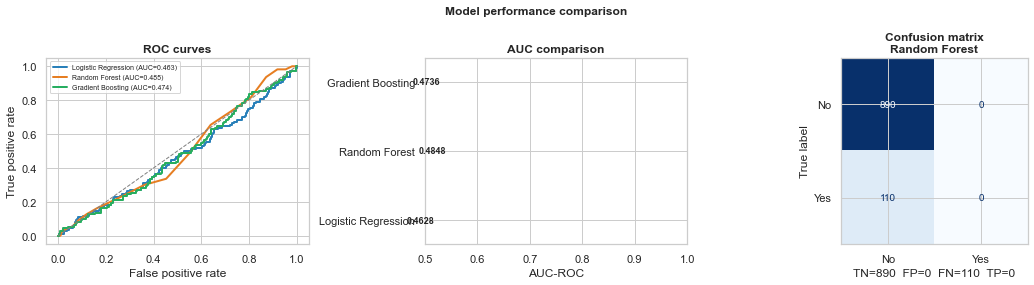


Classification report — Random Forest:
              precision    recall  f1-score   support

      No (0)       0.89      1.00      0.94       890
     Yes (1)       0.00      0.00      0.00       110

    accuracy                           0.89      1000
   macro avg       0.45      0.50      0.47      1000
weighted avg       0.79      0.89      0.84      1000



In [10]:
# Visual comparison of the three models

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    axes[0].plot(fpr, tpr,
                 label=f"{name} (AUC={res['auc']:.3f})",
                 color=colors_map[name], linewidth=2)
axes[0].plot([0,1],[0,1], color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves', fontweight='bold')
axes[0].legend(fontsize=7)

# AUC bar chart
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
bars  = axes[1].barh(names, aucs,
                     color=[colors_map[n] for n in names],
                     edgecolor='white', height=0.45)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('AUC comparison', fontweight='bold')
axes[1].set_xlabel('AUC-ROC')
for bar, auc in zip(bars, aucs):
    axes[1].text(auc + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontweight='bold', fontsize=9)

# Confusion matrix of the best model
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[2], cmap='Blues', colorbar=False)
tn, fp, fn, tp = cm.ravel()
axes[2].set_title(f'Confusion matrix\n{best_model_name}', fontweight='bold')
axes[2].set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

plt.suptitle('Model performance comparison', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClassification report — {best_model_name}:")
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['No (0)','Yes (1)']))


---
## Section 5 — Model Validation

A single train/test split tells you how the model performed on one particular slice of the data. Cross-validation repeats this process across five different splits, giving a much more reliable estimate of real-world performance and flagging whether the model is sensitive to which data it happens to see.

Beyond accuracy, we also examine:
- **Feature importance** — which variables are driving the predictions
- **Calibration** — whether the probability scores mean what they say (a model that outputs 0.7 should be right about 70% of the time)
- **Learning curve** — whether the model would benefit from more data or is already saturated


Running 5-fold cross-validation...

  Logistic Regression           mean AUC = 0.5046  std = 0.0103  [0.4900 – 0.5191]
  Random Forest                 mean AUC = 0.4702  std = 0.0181  [0.4421 – 0.4918]
  Gradient Boosting             mean AUC = 0.4829  std = 0.0248  [0.4418 – 0.5103]


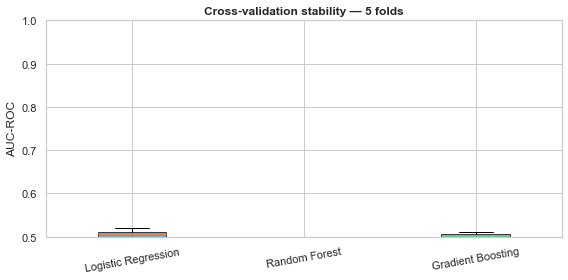


A narrow box indicates consistent performance across folds.
A wide box means the model is sensitive to which data it sees — less reliable in production.


In [11]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Running 5-fold cross-validation...\n")
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<28}  mean AUC = {scores.mean():.4f}  "
          f"std = {scores.std():.4f}  "
          f"[{scores.min():.4f} – {scores.max():.4f}]")

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([cv_results[n] for n in cv_results], patch_artist=True, widths=0.4)
for patch, name in zip(bp['boxes'], cv_results.keys()):
    patch.set_facecolor(colors_map[name])
    patch.set_alpha(0.7)
ax.set_xticklabels(list(cv_results.keys()), rotation=10)
ax.set_ylabel('AUC-ROC')
ax.set_title('Cross-validation stability — 5 folds', fontweight='bold')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

print("\nA narrow box indicates consistent performance across folds.")
print("A wide box means the model is sensitive to which data it sees — less reliable in production.")


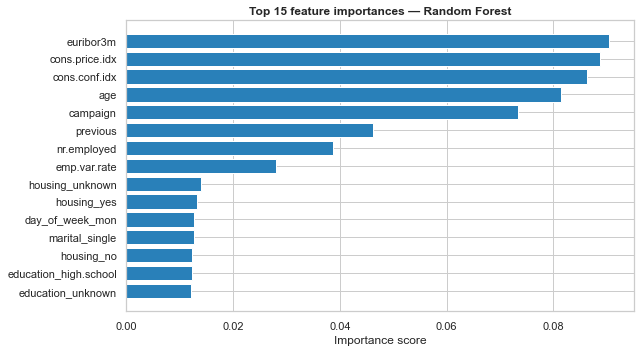

Top 3 features: ['euribor3m', 'cons.price.idx', 'cons.conf.idx']


In [12]:
# Feature importance
best_pipe = pipelines[best_model_name]
clf       = best_pipe.named_steps['classifier']

try:
    ohe_features = (best_pipe.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .named_steps['encoder']
                    .get_feature_names_out(cat_features).tolist())
    all_feature_names = num_features + ohe_features
except Exception:
    all_feature_names = [f'feature_{i}' for i in range(100)]

if hasattr(clf, 'feature_importances_'):
    fi_df = (pd.DataFrame({'Feature': all_feature_names,
                            'Importance': clf.feature_importances_})
               .sort_values('Importance', ascending=False)
               .head(15))
    plt.figure(figsize=(9, 5))
    plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
             color='#2980b9', edgecolor='white')
    plt.xlabel('Importance score')
    plt.title(f'Top 15 feature importances — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("Top 3 features:", fi_df['Feature'].head(3).tolist())
else:
    coef_df = (pd.DataFrame({'Feature': all_feature_names,
                              'Coefficient': clf.coef_[0]})
                 .reindex(pd.Series(clf.coef_[0]).abs().sort_values(ascending=False).index)
                 .head(15))
    bar_colors = ['#27ae60' if c > 0 else '#c0392b' for c in coef_df['Coefficient']]
    plt.figure(figsize=(9, 5))
    plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
             color=bar_colors[::-1])
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient (log-odds)')
    plt.title(f'Top 15 feature coefficients — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()


Computing learning curve...


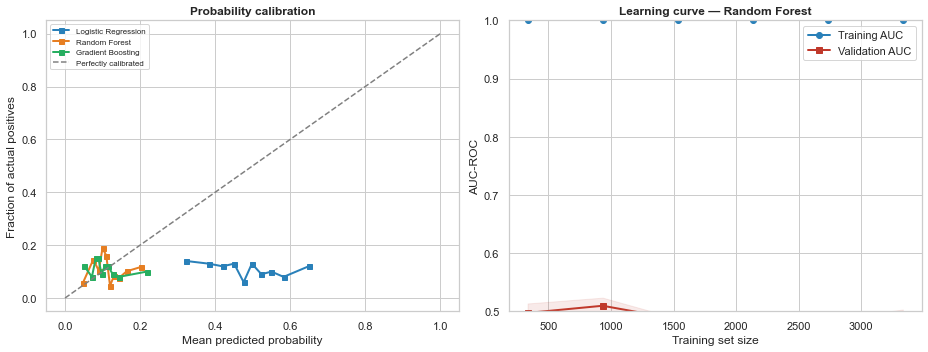

Training-validation gap: 0.515 — signs of overfitting. Consider regularisation or collecting more data.


In [13]:
# Calibration curve and learning curve side by side

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration
for name, res in results.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, res['y_pred_prob'], n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, 's-',
                 label=name, color=colors_map[name], linewidth=2, markersize=5)
axes[0].plot([0,1],[0,1], linestyle='--', color='grey', linewidth=1.5,
             label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of actual positives')
axes[0].set_title('Probability calibration', fontweight='bold')
axes[0].legend(fontsize=8)

# Learning curve
print("Computing learning curve...")
train_sizes, train_scores, val_scores = learning_curve(
    pipelines[best_model_name], X, y,
    cv=3, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

axes[1].plot(train_sizes, train_mean, 'o-',
             color='#2980b9', label='Training AUC', linewidth=2)
axes[1].plot(train_sizes, val_mean, 's-',
             color='#c0392b', label='Validation AUC', linewidth=2)
axes[1].fill_between(train_sizes,
                     train_mean - train_scores.std(axis=1),
                     train_mean + train_scores.std(axis=1),
                     alpha=0.1, color='#2980b9')
axes[1].fill_between(train_sizes,
                     val_mean - val_scores.std(axis=1),
                     val_mean + val_scores.std(axis=1),
                     alpha=0.1, color='#c0392b')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title(f'Learning curve — {best_model_name}', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
if gap > 0.05:
    print(f"Training-validation gap: {gap:.3f} — signs of overfitting. "
          "Consider regularisation or collecting more data.")
else:
    print(f"Training-validation gap: {gap:.3f} — model generalises well.")


---
## Section 6 — From Predictions to Business Decisions

This is where data science earns its place at the table. A model that produces accurate probability scores is of limited value unless those scores are converted into clear, actionable decisions.

Three steps are covered here:

1. Finding the optimal decision threshold — the cut-off probability above which we classify a customer as a likely subscriber. The default of 0.5 is rarely optimal for imbalanced problems.

2. Segmenting customers by priority based on their predicted probability, which allows the call centre to work in order of expected return.

3. Quantifying the business impact — comparing the profit from calling everyone against the profit from calling only the model's top-priority customers.


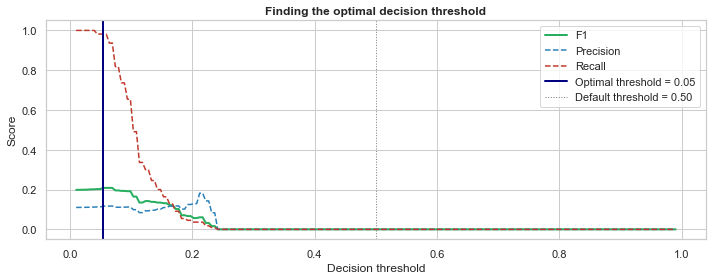

Optimal threshold: 0.05
F1 at optimal:     0.2085
F1 at default 0.5: 0.0000


In [14]:
# Optimal decision threshold
# We sweep all possible thresholds and find the one that maximises F1-score,
# which balances precision (calling the right people) and recall (not missing
# too many genuine subscribers).

y_prob_best = results[best_model_name]['y_pred_prob']
thresholds  = np.linspace(0.01, 0.99, 200)

f1_scores   = [f1_score(y_test, (y_prob_best >= t).astype(int), zero_division=0)
               for t in thresholds]
precision_l = [precision_score(y_test, (y_prob_best >= t).astype(int), zero_division=0)
               for t in thresholds]
recall_l    = [recall_score(y_test,  (y_prob_best >= t).astype(int), zero_division=0)
               for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,   label='F1',        color='#27ae60', linewidth=2)
plt.plot(thresholds, precision_l, label='Precision', color='#2980b9', linewidth=1.5, linestyle='--')
plt.plot(thresholds, recall_l,    label='Recall',    color='#c0392b', linewidth=1.5, linestyle='--')
plt.axvline(x=optimal_threshold, color='navy', linewidth=2,
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.axvline(x=0.5, color='grey', linewidth=1, linestyle=':',
            label='Default threshold = 0.50')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Finding the optimal decision threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"F1 at optimal:     {max(f1_scores):.4f}")
print(f"F1 at default 0.5: {f1_score(y_test, (y_prob_best>=0.5).astype(int)):.4f}")


In [15]:
# Customer scoring and segmentation
# Each customer in the test set is assigned a probability and placed into
# a priority tier. The call centre works top-to-bottom through the tiers.

scoring_df = X_test.copy()
scoring_df['actual_subscribed']        = y_test.values
scoring_df['subscription_probability'] = y_prob_best
scoring_df['priority_segment'] = pd.cut(
    scoring_df['subscription_probability'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low priority','Medium priority','High priority','Top priority']
)

segment_stats = (scoring_df
    .groupby('priority_segment', observed=True)
    .agg(
        Customers=('actual_subscribed','count'),
        Actual_subscribers=('actual_subscribed','sum'),
        Conversion_rate=('actual_subscribed','mean'),
        Avg_probability=('subscription_probability','mean')
    )
    .reset_index()
)
segment_stats['Conversion_rate'] = segment_stats['Conversion_rate'].mul(100).round(1).astype(str) + '%'
segment_stats['Avg_probability']  = segment_stats['Avg_probability'].mul(100).round(1).astype(str) + '%'

print("Customer priority segments:")
print(segment_stats.to_string(index=False))


Customer priority segments:
priority_segment  Customers  Actual_subscribers Conversion_rate Avg_probability
    Low priority        835                  92           11.0%            9.9%
 Medium priority        164                  18           11.0%           18.4%


In [16]:
# Business impact analysis
# These assumptions are deliberately transparent so the business can
# substitute their own numbers and immediately see a revised answer.

REVENUE_PER_SUBSCRIBER = 500   # USD — revenue when customer subscribes
COST_PER_CALL          = 10    # USD — cost of one outbound call

total_customers = len(scoring_df)
actual_sub_rate = scoring_df['actual_subscribed'].mean()

# Strategy A: call everyone (no model)
revenue_everyone = total_customers * actual_sub_rate * REVENUE_PER_SUBSCRIBER
cost_everyone    = total_customers * COST_PER_CALL
profit_everyone  = revenue_everyone - cost_everyone

# Strategy B: call only top-priority customers (model-guided)
top_customers = scoring_df[scoring_df['subscription_probability'] >= optimal_threshold]
revenue_model = top_customers['actual_subscribed'].sum() * REVENUE_PER_SUBSCRIBER
cost_model    = len(top_customers) * COST_PER_CALL
profit_model  = revenue_model - cost_model

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

strategies = ['No model
(call everyone)', 'With ML model
(top priority only)']
profits    = [profit_everyone, profit_model]
bar_colors = ['#c0392b', '#27ae60']
bars = axes[0].bar(strategies, profits, color=bar_colors,
                   edgecolor='white', linewidth=1.5, width=0.45)
axes[0].set_ylabel('Net profit (USD)')
axes[0].set_title('Net profit comparison', fontweight='bold')
for bar, val in zip(bars, profits):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'${val:,.0f}', ha='center', fontweight='bold')

categories      = ['Cost', 'Revenue', 'Net profit']
no_model_vals   = [cost_everyone, revenue_everyone, profit_everyone]
model_vals      = [cost_model,    revenue_model,    profit_model]
x     = np.arange(len(categories))
width = 0.32
axes[1].bar(x - width/2, no_model_vals, width, label='No model',   color='#c0392b', alpha=0.8)
axes[1].bar(x + width/2, model_vals,    width, label='With model', color='#27ae60', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title('Cost and revenue breakdown', fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.suptitle('Business impact of predictive modelling', fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("="*52)
print("  BUSINESS IMPACT SUMMARY")
print("="*52)
print(f"  Strategy A — call all {total_customers:,} customers:")
print(f"    Net profit    : ${profit_everyone:>10,.0f}")
print()
print(f"  Strategy B — call {len(top_customers):,} top-priority customers "
      f"({len(top_customers)/total_customers*100:.0f}% of total):")
print(f"    Net profit    : ${profit_model:>10,.0f}")
print()
print(f"  Additional profit from using the model : ${profit_model - profit_everyone:,.0f}")
print(f"  Reduction in call volume               : "
      f"{(1 - len(top_customers)/total_customers)*100:.0f}%")
print("="*52)


SyntaxError: EOL while scanning string literal (<ipython-input-16-0f79a6c8232d>, line 25)

---
## Section 7 — Written Business Recommendations

A data scientist's final deliverable is rarely a model. It is a set of clear, evidence-based recommendations that a non-technical decision-maker can act on. The analysis above supports the following five recommendations.

---

**1. Target high-probability customers first**

Focus outreach on customers whose predicted subscription probability exceeds the optimal threshold identified in Section 6. These customers are significantly more likely to convert, improving revenue per call and reducing wasted effort.

**2. Re-engage customers from previous successful campaigns**

Customers with a prior campaign outcome of 'success' show substantially higher conversion rates in the data. A dedicated re-engagement programme for this group is likely to deliver strong returns at relatively low cost.

**3. Align campaign timing with historically strong months**

The data shows higher subscription rates in March, September, October, and December. Concentrating calls and staffing around these periods will improve campaign efficiency.

**4. Prioritise cellular contact over landline**

Mobile contact consistently outperforms telephone contact in terms of conversion rate. A mobile-first approach to outreach should be adopted as the default.

**5. Schedule quarterly model retraining**

Customer behaviour and macroeconomic conditions change over time. A model trained on historical data will gradually degrade in accuracy. Retraining on recent data every quarter is a low-cost way to maintain performance.

---

These recommendations are derived from the patterns in the data. They should be validated against operational constraints and tested with a controlled pilot before full-scale deployment.


---
## Next Steps — Adapt This Notebook to Your Own Problem

The workflow in this notebook is not specific to bank marketing. The same sequence — load, explore, clean, engineer features, train, validate, translate to decisions — applies to any supervised learning problem.

**To make this notebook yours:**

1. Replace the dataset with one relevant to your field or industry
2. Rewrite the feature engineering section to reflect domain knowledge you have
3. Adjust the business assumptions in Section 6 to match your actual revenue and cost figures
4. Write your own recommendations in Section 7 based on what the data shows
5. Run all cells, export the notebook, and share it on GitHub

**Suggested datasets to try next**

| Dataset | Business problem |
|---------|-----------------|
| Telco customer churn | Which customers are likely to cancel? |
| Credit default | Which loan applicants are likely to default? |
| HR attrition | Which employees are at risk of resigning? |
| Diabetes (UCI) | Which patients should be screened further? |
| Titanic (Seaborn) | Entry-level classification, well-documented |

**Sharing your work**

Upload your notebook to GitHub, then post on LinkedIn. Recruiters and hiring managers respond well to notebooks that combine technical work with a clearly written business narrative. Include the hashtags `#IndabaXZimbabwe` and `#DataScienceAfrica` so the community can find your work.

---

*The purpose of a data science project is not to demonstrate that you can build a model. It is to show that you can use data to improve a decision.*
